In [15]:
import joblib

joblib.dump(clf,    MODELS_DIR / "classifier.joblib")
joblib.dump(scaler, MODELS_DIR / "scaler.joblib")

print(f"Model saved  : {MODELS_DIR / 'classifier.joblib'}")
print(f"Scaler saved : {MODELS_DIR / 'scaler.joblib'}")
print("\n03_modelling.ipynb complete. Ready for Phase 5 — Dashboard!")

Model saved  : ..\models\classifier.joblib
Scaler saved : ..\models\scaler.joblib

03_modelling.ipynb complete. Ready for Phase 5 — Dashboard!


## 8. Save Model

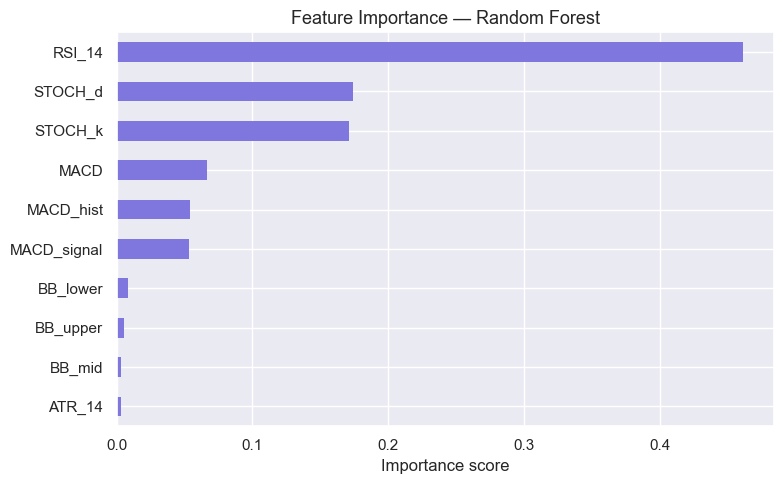

Chart saved.


In [14]:
importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values()

plt.figure(figsize=(8, 5))
importances.plot.barh(color="#7F77DD", edgecolor="none")
plt.title("Feature Importance — Random Forest", fontsize=13)
plt.xlabel("Importance score")
plt.tight_layout()
plt.savefig("../data/processed/08_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

## 7. Feature Importance
Which indicators matter most to the model?

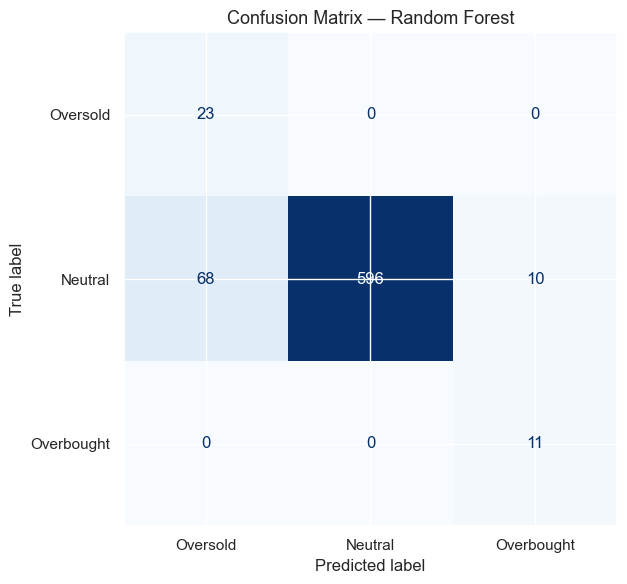

Chart saved.


In [13]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Oversold", "Neutral", "Overbought"])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.title("Confusion Matrix — Random Forest", fontsize=13)
plt.tight_layout()
plt.savefig("../data/processed/07_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

## 6. Confusion Matrix

In [12]:
mlflow.set_experiment("overbought-oversold-detection")

with mlflow.start_run():
    # Log parameters
    mlflow.log_param("model",        "RandomForest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth",    6)
    mlflow.log_param("smote",        True)
    mlflow.log_param("train_size",   len(X_train_res))
    mlflow.log_param("test_size",    len(X_test))

    # Train
    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train_res, y_train_res)

    # Evaluate
    preds = clf.predict(X_test_sc)
    acc   = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds,
                target_names=["Oversold", "Neutral", "Overbought"],
                output_dict=True)

    # Log metrics
    mlflow.log_metric("accuracy",            acc)
    mlflow.log_metric("precision_oversold",  report["Oversold"]["precision"])
    mlflow.log_metric("precision_neutral",   report["Neutral"]["precision"])
    mlflow.log_metric("precision_overbought",report["Overbought"]["precision"])
    mlflow.sklearn.log_model(clf, "random_forest_model")

    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds,
          target_names=["Oversold", "Neutral", "Overbought"]))

print("Run logged to MLflow.")

2026/05/11 23:58:06 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/11 23:58:06 INFO mlflow.store.db.utils: Updating database tables
2026/05/11 23:58:07 INFO mlflow.tracking.fluent: Experiment with name 'overbought-oversold-detection' does not exist. Creating a new experiment.
2026/05/11 23:58:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 23:58:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.8898

Classification Report:
              precision    recall  f1-score   support

    Oversold       0.25      1.00      0.40        23
     Neutral       1.00      0.88      0.94       674
  Overbought       0.52      1.00      0.69        11

    accuracy                           0.89       708
   macro avg       0.59      0.96      0.68       708
weighted avg       0.97      0.89      0.92       708

Run logged to MLflow.


## 5. Train Random Forest with MLflow Tracking

In [11]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Before SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c}")

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_sc, y_train)

print("\nAfter SMOTE:")
unique, counts = np.unique(y_train_res, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c}")

Before SMOTE:
  Class 0: 54
  Class 1: 2690
  Class 2: 88

After SMOTE:
  Class 0: 2690
  Class 1: 2690
  Class 2: 2690


## 4. Scale Features + Apply SMOTE
StandardScaler normalises all features to same range.
SMOTE synthetically oversamples minority classes to balance the dataset.

In [10]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size : {len(X_train)} rows")
print(f"Test size  : {len(X_test)} rows")
print(f"\nTrain class distribution:")
for label, name in zip([0,1,2], ["Oversold", "Neutral", "Overbought"]):
    count = (y_train == label).sum()
    print(f"  {name:12s}: {count:>4} ({count/len(y_train)*100:.1f}%)")

Train size : 2832 rows
Test size  : 708 rows

Train class distribution:
  Oversold    :   54 (1.9%)
  Neutral     : 2690 (95.0%)
  Overbought  :   88 (3.1%)


## 3. Walk-Forward Train/Test Split
We split by time — no random shuffling to prevent data leakage.
80% train, 20% test.

In [9]:
FEATURE_COLS = [
    "RSI_14",
    "MACD", "MACD_signal", "MACD_hist",
    "BB_upper", "BB_mid", "BB_lower",
    "ATR_14",
    "STOCH_k", "STOCH_d"
]

# Keep only columns that exist
FEATURE_COLS = [c for c in FEATURE_COLS if c in combined.columns]

X = combined[FEATURE_COLS].copy()
y = combined["label"].copy()

# Fix shape mismatch — reset index to avoid duplicate date index issues
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

X.dropna(inplace=True)
y = y.loc[X.index]

print(f"Features used  : {FEATURE_COLS}")
print(f"X shape        : {X.shape}")
print(f"y shape        : {y.shape}")
print(f"\nClass distribution:")
for label, name in zip([0,1,2], ["Oversold", "Neutral", "Overbought"]):
    count = (y == label).sum()
    print(f"  {name:12s}: {count:>4} ({count/len(y)*100:.1f}%)")

Features used  : ['RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_upper', 'BB_mid', 'BB_lower', 'ATR_14', 'STOCH_k', 'STOCH_d']
X shape        : (3540, 10)
y shape        : (3540,)

Class distribution:
  Oversold    :   77 (2.2%)
  Neutral     : 3364 (95.0%)
  Overbought  :   99 (2.8%)


## 2. Prepare Feature Matrix

In [7]:
TICKERS = [
    "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "WIPRO.NS"
]

dfs = []
for ticker in TICKERS:
    path = PROCESSED_DIR / f"{ticker.replace('.', '_')}_features.csv"
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df["ticker"] = ticker
    dfs.append(df)

combined = pd.concat(dfs).sort_index()
print(f"Total rows     : {len(combined)}")
print(f"Total columns  : {len(combined.columns)}")
print(f"Label counts   :\n{combined['label'].value_counts().sort_index()}")

Total rows     : 3540
Total columns  : 17
Label counts   :
label
0      77
1    3364
2      99
Name: count, dtype: int64


## 1. Load Processed Feature Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import warnings
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


In [5]:
pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

Note: you may need to restart the kernel to use updated packages.


In [4]:

pip install mlflow

Note: you may need to restart the kernel to use updated packages.


# 03 — Modelling
## Stock Overbought / Oversold Detection — NSE/BSE
**Goal:** Train a Random Forest classifier to detect overbought/oversold conditions.
Uses SMOTE for class imbalance and MLflow for experiment tracking.